<a href="https://colab.research.google.com/github/kinzakhan099/DMA-LMS/blob/main/superstoreanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
import os
os.listdir()

['.config', 'Sample - Superstore.csv', 'sample_data']

In [7]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df['Price_per_Unit'] = df['Sales'] / df['Quantity']

In [10]:
df['Customer_Spending'] = df.groupby('Customer Name')['Sales'].transform('sum')

In [11]:
df['Transactions'] = df.groupby('Customer Name')['Order ID'].transform('count')

In [12]:
df['Advertising_Cost'] = df['Sales'] * np.random.uniform(0.05, 0.20, len(df))

In [13]:
df['Store_Area'] = np.random.randint(500, 6000, len(df))

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Price_per_Unit,Customer_Spending,Transactions,Advertising_Cost,Store_Area
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,130.9800,1148.7800,5,47.260056,4227
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,243.9800,1148.7800,5,129.800513,5479
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.3100,1119.4830,9,2.876433,2544
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,191.5155,2602.5755,15,146.763359,2049
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.1840,2602.5755,15,1.741797,1160


In [15]:
customer_name = 'Claire Gute'

# Filter rows
customer_orders = df[df['Customer Name'] == customer_name]

# Display relevant columns
customer_orders[['Order ID','Sales','Quantity','Profit','Customer_Spending','Transactions','Price_per_Unit','Advertising_Cost','Store_Area']]

,Order ID,Sales,Quantity,Profit,Customer_Spending,Transactions,Price_per_Unit,Advertising_Cost,Store_Area
0,CA-2016-152156,261.960,2,41.9136,1148.78,5,130.980,47.260056,4227
1,CA-2016-152156,731.940,3,219.5820,1148.78,5,243.980,129.800513,5479
5491,CA-2017-164098,18.160,2,1.8160,1148.78,5,9.080,1.421376,2118
6877,US-2015-123918,131.376,6,-95.2476,1148.78,5,21.896,13.288565,3263
6878,US-2015-123918,5.344,1,1.8704,1148.78,5,5.344,0.717933,2225


In [16]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Price_per_Unit,Customer_Spending,Transactions,Advertising_Cost,Store_Area
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,60.919569,3593.694483,15.691015,29.070981,3229.681909
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,142.927440,2837.907488,6.654997,90.026489,1580.973552
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.336000,4.833000,1.000000,0.028272,500.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,5.470000,1669.135000,11.000000,1.995618,1863.250000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,16.270000,2874.338000,15.000000,6.386458,3201.500000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,63.940000,4715.466000,20.000000,25.150289,4601.500000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,3773.080000,25043.050000,37.000000,4067.234430,5999.000000


In [17]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print("Number of Outliers:", outliers.shape[0])

Lower Bound: -271.71000000000004
Upper Bound: 498.93
Number of Outliers: 1167


In [18]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

In [19]:
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (9994, 21)
After: (8827, 21)


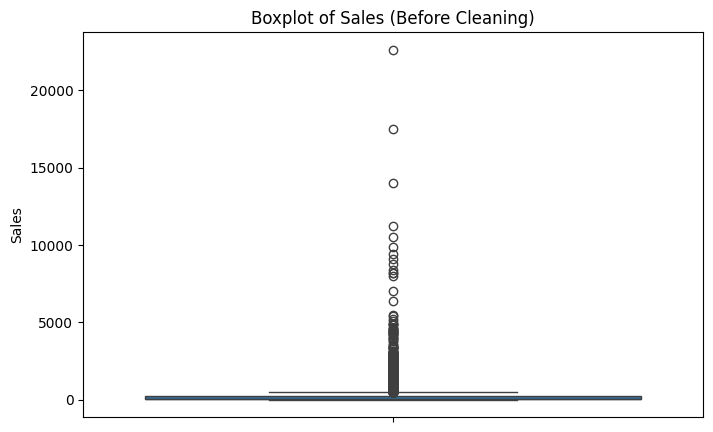

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Sales'])
plt.title("Boxplot of Sales (Before Cleaning)")
plt.show()

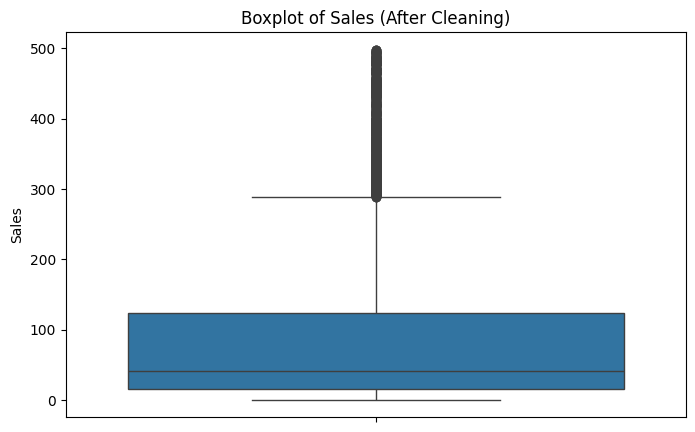

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df_clean['Sales'])
plt.title("Boxplot of Sales (After Cleaning)")
plt.show()

In [22]:
df_clean['Sales'].describe()

,Sales
count,8827.000000
mean,92.864853
std,114.045078
min,0.444000
25%,15.008000
50%,40.880000
75%,124.225000
max,498.260000


In [23]:
df_clean.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000,8827.000000
mean,5016.375892,55373.635663,92.864853,3.608587,0.157606,11.198644
std,2888.406540,31974.536840,114.045078,2.129308,0.211531,49.066101
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-1181.282400
25%,2508.500000,23320.000000,15.008000,2.000000,0.000000,1.702400
50%,5028.000000,59801.000000,40.880000,3.000000,0.200000,7.437600
75%,7517.500000,90008.000000,124.225000,5.000000,0.200000,21.335400
max,9994.000000,99301.000000,498.260000,14.000000,0.800000,240.859500


In [24]:
df_clean.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

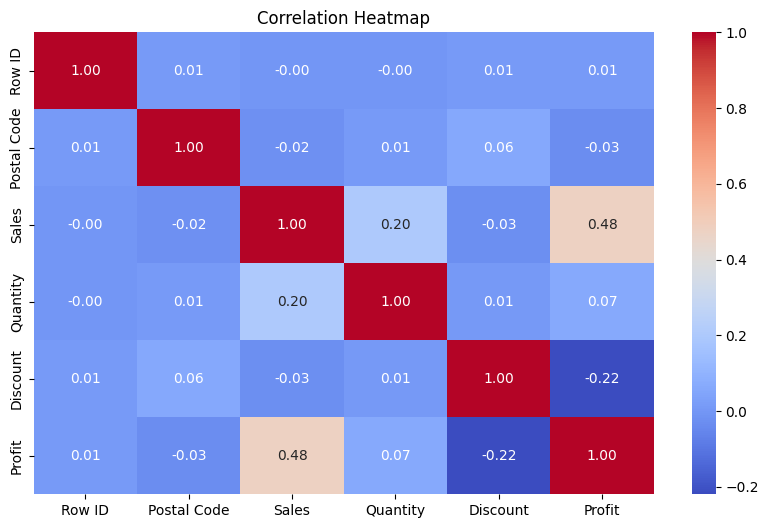

In [26]:
 corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

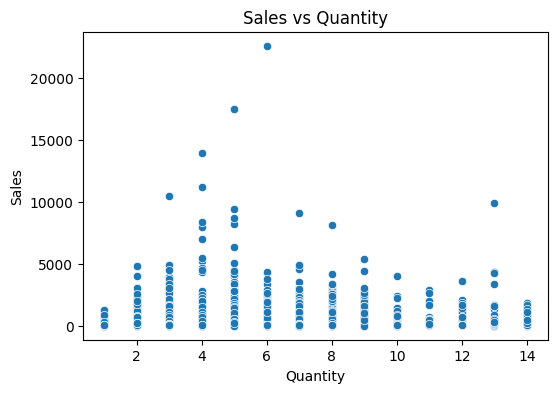

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Quantity'], y=df['Sales'])
plt.title("Sales vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

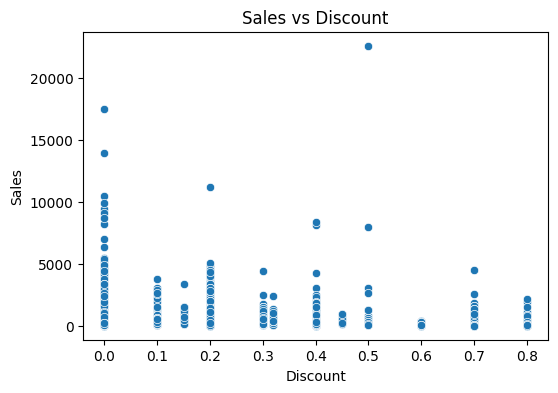

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Discount'], y=df['Sales'])
plt.title("Sales vs Discount")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.show()

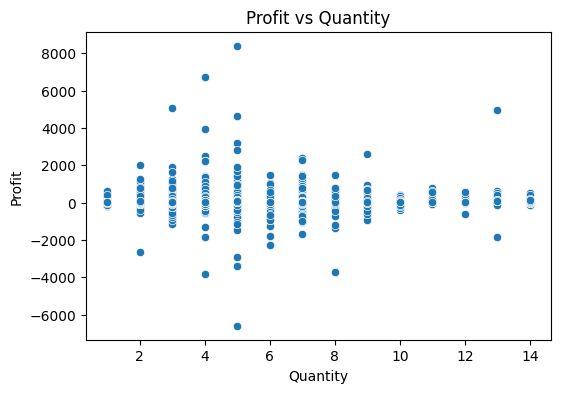

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Quantity'], y=df['Profit'])
plt.title("Profit vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Profit")
plt.show()

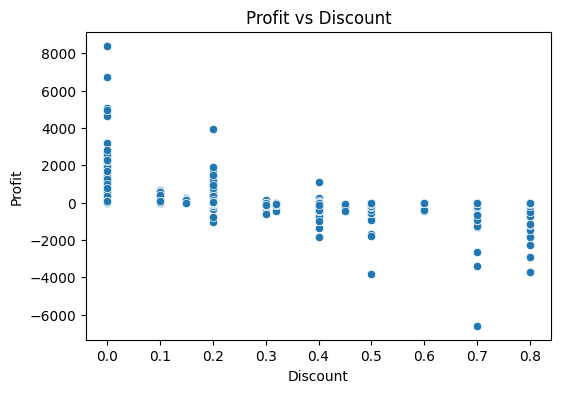

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Discount'], y=df['Profit'])
plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

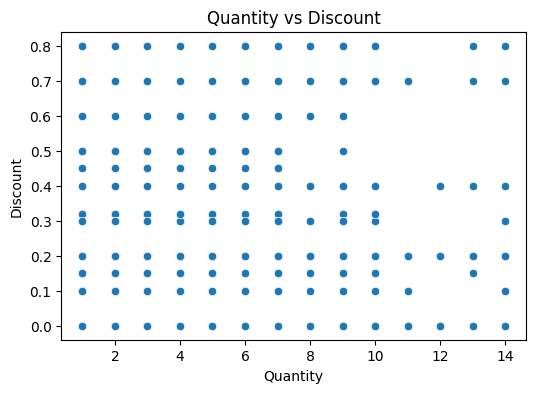

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Quantity'], y=df['Discount'])
plt.title("Quantity vs Discount")
plt.xlabel("Quantity")
plt.ylabel("Discount")
plt.show()

--- MODEL RESULTS ---
Slope (m): 56.24
Intercept (b): 16.73
Equation: Sales = 56.24 * Quantity + 16.73
R-squared: 0.0403

--- INTERPRETATION ---
Slope: For every 1 additional unit sold, Sales increase by $56.24 on average.
Intercept: If Quantity is 0, the baseline Sales value is $16.73 (theoretical baseline).

--- PREDICTION SCENARIOS ---
If Quantity is 2, Predicted Sales are: $129.21
If Quantity is 15, Predicted Sales are: $860.35
If Quantity is 50, Predicted Sales are: $2828.82


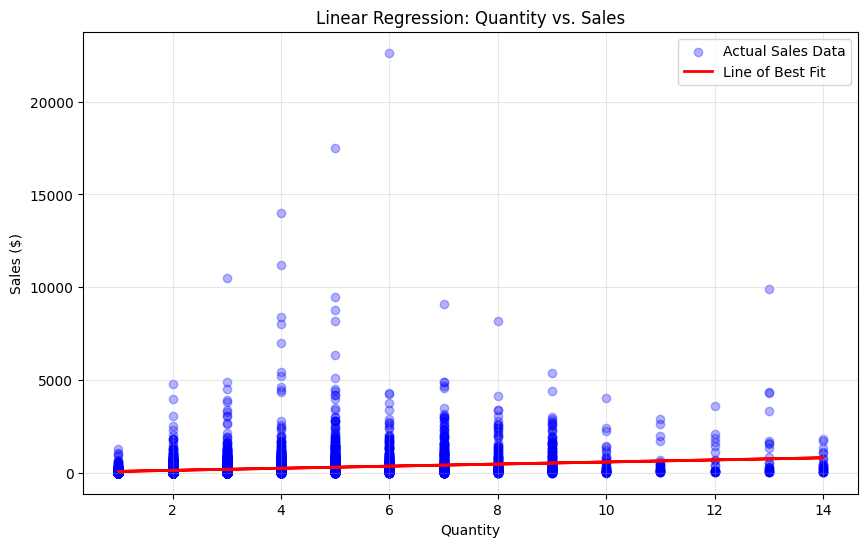

In [34]:
# --- REGRESSION & PREDICTION SPECIALIST ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Scenerio A: Quantity vs Sales

# 1. LOAD DATA & PREPARE VARIABLES
# We add encoding='windows-1252' to handle special characters
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
except UnicodeDecodeError:
    # If windows-1252 fails, try latin1
    df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Defining variables based on group findings (Quantity -> Sales)
X = df[['Quantity']].values
y = df['Sales'].values

# 2. APPLY LINEAR REGRESSION
model = LinearRegression()
model.fit(X, y)

# Get key values
slope = model.coef_[0]      # The 'm' in y = mx + b
intercept = model.intercept_ # The 'b' in y = mx + b
r2 = model.score(X, y)      # R-squared value

# 3. PRINT EQUATION & INTERPRETATION
print("--- MODEL RESULTS ---")
print(f"Slope (m): {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")
print(f"Equation: Sales = {slope:.2f} * Quantity + {intercept:.2f}")
print(f"R-squared: {r2:.4f}")
print("\n--- INTERPRETATION ---")
print(f"Slope: For every 1 additional unit sold, Sales increase by ${slope:.2f} on average.")
print(f"Intercept: If Quantity is 0, the baseline Sales value is ${intercept:.2f} (theoretical baseline).")

# 4. PERFORM 3 PREDICTION SCENARIOS
# We predict sales for Low (2 units), Medium (15 units), and Bulk (50 units) orders
scenarios = np.array([[2], [15], [50]])
predictions = model.predict(scenarios)

print("\n--- PREDICTION SCENARIOS ---")
for qty, pred in zip(scenarios.flatten(), predictions):
    print(f"If Quantity is {qty}, Predicted Sales are: ${pred:.2f}")

# 5. VISUALIZATION (Line of Best Fit)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual Sales Data') # Plot data points
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Line of Best Fit') # Plot regression line
plt.title('Linear Regression: Quantity vs. Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- RESULTS FOR SCENARIO B (Quantity vs. Profit) ---
Equation: Profit = 6.98 * Quantity + 2.22
Slope: 6.98
Intercept: 2.22
R-squared: 0.0044

--- PREDICTIONS ---
If Quantity = 2, Predicted Profit = $16.17
If Quantity = 15, Predicted Profit = $106.85
If Quantity = 50, Predicted Profit = $350.98


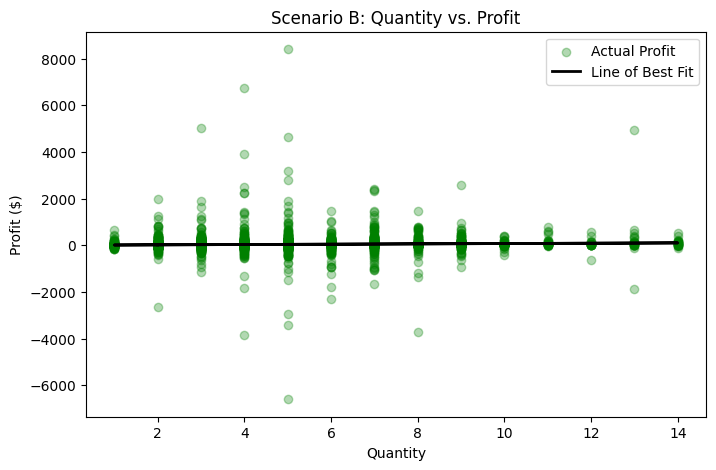

In [35]:
# --- SCENARIO B: QUANTITY vs. PROFIT ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load Data (if not already loaded)
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
except:
    df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Define Variables
X_b = df[['Quantity']].values
y_b = df['Profit'].values

# Fit Model
model_b = LinearRegression()
model_b.fit(X_b, y_b)

# Get Equation Values
slope_b = model_b.coef_[0]
intercept_b = model_b.intercept_
r2_b = model_b.score(X_b, y_b)

# Print Results
print("--- RESULTS FOR SCENARIO B (Quantity vs. Profit) ---")
print(f"Equation: Profit = {slope_b:.2f} * Quantity + {intercept_b:.2f}")
print(f"Slope: {slope_b:.2f}")
print(f"Intercept: {intercept_b:.2f}")
print(f"R-squared: {r2_b:.4f}")

# Predictions (2, 15, 50 units)
scenarios_b = np.array([[2], [15], [50]])
preds_b = model_b.predict(scenarios_b)

print("\n--- PREDICTIONS ---")
for qty, pred in zip(scenarios_b.flatten(), preds_b):
    print(f"If Quantity = {qty}, Predicted Profit = ${pred:.2f}")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X_b, y_b, color='green', alpha=0.3, label='Actual Profit')
plt.plot(X_b, model_b.predict(X_b), color='black', linewidth=2, label='Line of Best Fit')
plt.title('Scenario B: Quantity vs. Profit')
plt.xlabel('Quantity')
plt.ylabel('Profit ($)')
plt.legend()
plt.show()

--- RESULTS FOR SCENARIO C (Discount vs. Profit) ---
Equation: Profit = -249.05 * Discount + 67.56
Slope: -249.05
Intercept: 67.56
R-squared: 0.0482

--- PREDICTIONS ---
If Discount = 10%, Predicted Profit = $42.65
If Discount = 30%, Predicted Profit = $-7.16
If Discount = 50%, Predicted Profit = $-56.97


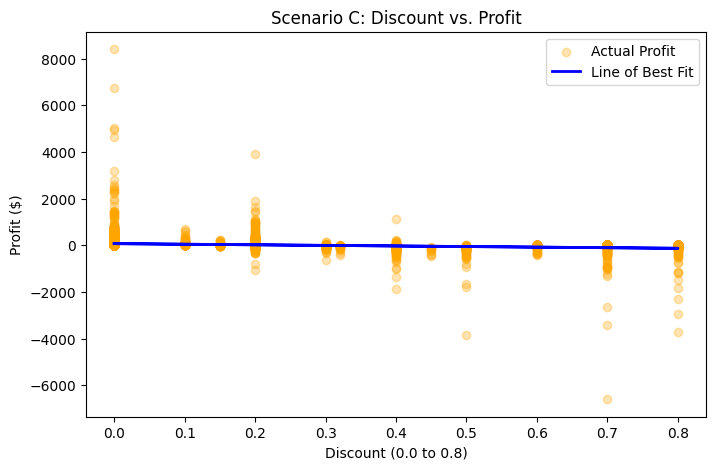

In [36]:
# --- SCENARIO C: DISCOUNT vs. PROFIT ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load Data (if not already loaded)
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
except:
    df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Define Variables
X_c = df[['Discount']].values
y_c = df['Profit'].values

# Fit Model
model_c = LinearRegression()
model_c.fit(X_c, y_c)

# Get Equation Values
slope_c = model_c.coef_[0]
intercept_c = model_c.intercept_
r2_c = model_c.score(X_c, y_c)

# Print Results
print("--- RESULTS FOR SCENARIO C (Discount vs. Profit) ---")
print(f"Equation: Profit = {slope_c:.2f} * Discount + {intercept_c:.2f}")
print(f"Slope: {slope_c:.2f}")
print(f"Intercept: {intercept_c:.2f}")
print(f"R-squared: {r2_c:.4f}")

# Predictions (10%, 30%, 50% discount)
scenarios_c = np.array([[0.10], [0.30], [0.50]])
preds_c = model_c.predict(scenarios_c)

print("\n--- PREDICTIONS ---")
for disc, pred in zip(scenarios_c.flatten(), preds_c):
    print(f"If Discount = {disc*100:.0f}%, Predicted Profit = ${pred:.2f}")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X_c, y_c, color='orange', alpha=0.3, label='Actual Profit')
plt.plot(X_c, model_c.predict(X_c), color='blue', linewidth=2, label='Line of Best Fit')
plt.title('Scenario C: Discount vs. Profit')
plt.xlabel('Discount (0.0 to 0.8)')
plt.ylabel('Profit ($)')
plt.legend()
plt.show()